Sử dụng thiết bị: cuda
Loaded: clean_student_data_v2.csv
Shape: (340000, 30)
X shape after drop: (340000, 18)
y shape: (340000,)
Used GroupShuffleSplit by student_id.
Train size: (272000, 18) | Test size: (68000, 18)
Train(sub) size: (244800, 18) | Val size: (27200, 18)
Categorical features (2): ['course_code', 'study_format']
Numerical features (16): ['semester_number', 'credits_unit', 'last_score', 'mean_prev_score', 'score_trend', 'score_stability', 'score_stability_cv', 'recent_improvement', 'n_assessments', 'weekly_study_hours'] ...
X_tr_transformed : (244800, 79)
X_val_transformed: (27200, 79)
X_test_transformed: (68000, 79)
Total feature names: 79
Epoch 01/80 | Train Loss: 0.4021 | Val Loss: 0.1997
Epoch 02/80 | Train Loss: 0.2443 | Val Loss: 0.1997
Epoch 03/80 | Train Loss: 0.2369 | Val Loss: 0.1971
Epoch 04/80 | Train Loss: 0.2342 | Val Loss: 0.1999
Epoch 05/80 | Train Loss: 0.2323 | Val Loss: 0.1947
Epoch 06/80 | Train Loss: 0.2316 | Val Loss: 0.1970
Epoch 07/80 | Train Loss:

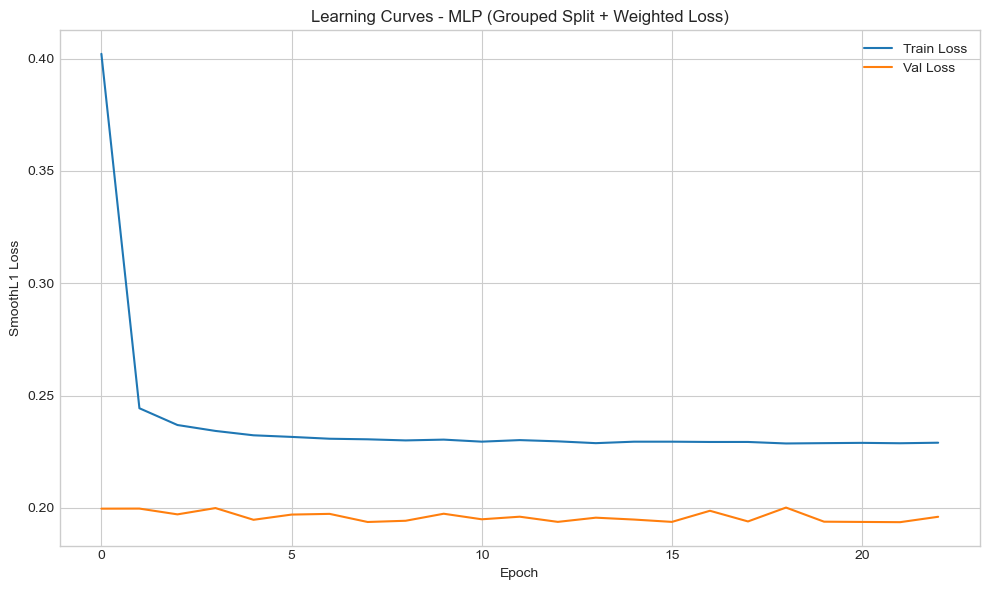


Kết quả mô hình trên TEST:
 - MAE : 0.5113
 - RMSE: 0.6408
 - R²  : 0.7180


In [6]:
# =========================================================
# MLP PyTorch - Preprocessing chuẩn (Group by student_id)
# - Fit preprocessor trên TRAIN בלבד
# - Có VALIDATION riêng để early stopping
# - TEST dùng để đánh giá cuối
# =========================================================

# === PHẦN 0: IMPORT & THIẾT BỊ ===
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {device}")

# === PHẦN 1: LOAD DATA ===
# === PHẦN 1: LOAD DATA ===
import os

# 1) Tìm file theo nhiều khả năng (ưu tiên cùng thư mục notebook)
DATA_CANDIDATES = [
    "clean_student_data_v2.csv",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy clean_student_data_v2.csv. "
        "Hãy đặt file cùng thư mục notebook hoặc sửa DATA_CANDIDATES."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")

# === Target & drop columns theo preprocessing của bạn ===
TARGET_COLUMN = "raw_score"

# 2) Drop để tránh leakage + bỏ cột không cần thiết
#    - Giữ: historical + efficiency + course_difficulty + study_load + subject_type_num
DROP_COLUMNS = [
    "year",
    "student_id",
    "raw_score",
    "cumulative_gpa",
    "current_semester_gpa",
    "previous_courses_taken",
    "previous_credits_earned",
    "expected_difficulty",
    "subject_type",
    "fail_rate_general",
    "fail_rate_major",
    "subject_type_num"
]

DROP_COLUMNS = [c for c in DROP_COLUMNS if c in df.columns]

X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET_COLUMN]
groups = df["student_id"]

print(f"X shape after drop: {X.shape}")
print(f"y shape: {y.shape}")

# 3) Ablation nhanh: bật/tắt full_interaction_feature
USE_FULL_INTERACTION = False
if not USE_FULL_INTERACTION and "full_interaction_feature" in X.columns:
    X = X.drop(columns=["full_interaction_feature"])
    print("[Ablation] Dropped full_interaction_feature")


# === PHẦN 2: GROUP SPLIT TRAIN/TEST ===
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_raw = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()
groups_train = groups.iloc[train_idx].copy()

X_test_raw = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print(f"Used GroupShuffleSplit by student_id.")
print(f"Train size: {X_train_raw.shape} | Test size: {X_test_raw.shape}")

# === PHẦN 3: TÁCH VALIDATION TỪ TRAIN (cũng theo group) ===
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
tr_idx, val_idx = next(gss_val.split(X_train_raw, y_train, groups=groups_train))

X_tr_raw = X_train_raw.iloc[tr_idx].copy()
y_tr = y_train.iloc[tr_idx].copy()

X_val_raw = X_train_raw.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()

print(f"Train(sub) size: {X_tr_raw.shape} | Val size: {X_val_raw.shape}")

# === PHẦN 4: PREPROCESSOR (OneHot + StandardScaler) ===
# Ưu tiên đúng 2 categorical bạn đã log
default_cat = [c for c in ["course_code", "study_format"] if c in X_tr_raw.columns]
if len(default_cat) == 0:
    categorical_features = X_tr_raw.select_dtypes(include=["object", "category"]).columns.tolist()
else:
    categorical_features = default_cat

numerical_features = X_tr_raw.select_dtypes(include=np.number).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features[:10]} ...")

# Tương thích sklearn các version
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categorical_features),
        ("num", StandardScaler(), numerical_features),
    ],
    remainder="drop"
)

preprocessing_pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# Fit trên train(sub) và transform val/test
X_tr = preprocessing_pipeline.fit_transform(X_tr_raw)
X_val = preprocessing_pipeline.transform(X_val_raw)
X_test = preprocessing_pipeline.transform(X_test_raw)

feature_names = preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(f"X_tr_transformed : {X_tr.shape}")
print(f"X_val_transformed: {X_val.shape}")
print(f"X_test_transformed: {X_test.shape}")
print(f"Total feature names: {len(feature_names)}")

# === PHẦN 5: CHUẨN BỊ TENSOR & DATALOADER ===
X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_tr_tensor = torch.tensor(y_tr.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Weighted samples (giữ logic bạn đang dùng)
# y < 5.0 -> weight 2.0
sample_weights = np.where(y_tr.values < 5.0, 2.0, 1.0).astype(np.float32)
w_tr_tensor = torch.tensor(sample_weights).view(-1, 1)

batch_size = 128

train_loader = DataLoader(
    TensorDataset(X_tr_tensor, y_tr_tensor, w_tr_tensor),
    batch_size=batch_size, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size, shuffle=False
)

# === PHẦN 6: MLP MODEL (Deep + BN + Dropout + L2) ===
input_dim = X_tr.shape[1]

class MLPDeep(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.SiLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLPDeep(input_dim).to(device)

# SmoothL1Loss + weighted
loss_fn = nn.SmoothL1Loss(reduction="none")
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# === PHẦN 7: TRAIN + EARLY STOPPING (theo VAL) ===
best_val_loss = float("inf")
best_model_path = "best_mlp_grouped_v6.pt"

patience = 15
patience_counter = 0
epochs = 80

train_losses, val_losses = [], []

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    total_train_loss = 0.0

    for xb, yb, wb in train_loader:
        xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)

        pred = model(xb)
        loss = loss_fn(pred, yb)             # shape (batch, 1)
        weighted_loss = (loss * wb).mean()

        optimizer.zero_grad()
        weighted_loss.backward()
        optimizer.step()

        total_train_loss += weighted_loss.item() * xb.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)

    # ---- Val ----
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb).mean()
            total_val_loss += loss.item() * xb.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss - 1e-4:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping tại epoch {epoch+1}")
            break

# Load best
model.load_state_dict(torch.load(best_model_path, map_location=device))
print(f"Loaded best model from: {best_model_path}")

# === PHẦN 8: LEARNING CURVES ===
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 Loss")
plt.title("Learning Curves - MLP (Grouped Split + Weighted Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === PHẦN 9: EVALUATION ON TEST ===
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor.to(device)).squeeze().cpu().numpy()

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print("\nKết quả mô hình trên TEST:")
print(f" - MAE : {mae:.4f}")
print(f" - RMSE: {rmse:.4f}")
print(f" - R²  : {r2:.4f}")

# =========================================================
# PHẦN 10 (OPTIONAL): PERMUTATION IMPORTANCE (nhẹ)
# - Lấy sample nhỏ để chạy nhanh
# =========================================================

def torch_permutation_importance(
    model,
    X_tensor,
    y_true_np,
    metric_fn=mean_squared_error,
    n_repeats=3,
    sample_size=5000,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    n = X_tensor.shape[0]
    idx = rng.choice(n, size=min(sample_size, n), replace=False)

    X_small = X_tensor[idx].clone()
    y_small = y_true_np.iloc[idx].values

    model.eval()
    with torch.no_grad():
        base_pred = model(X_small.to(device)).cpu().numpy().reshape(-1)

    base_score = metric_fn(y_small, base_pred)

    importances = np.zeros(X_small.shape[1], dtype=np.float32)

    for col in range(X_small.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_small.clone()
            perm_idx = torch.randperm(X_perm.shape[0])
            X_perm[:, col] = X_perm[perm_idx, col]

            with torch.no_grad():
                pred = model(X_perm.to(device)).cpu().numpy().reshape(-1)

            score = metric_fn(y_small, pred)
            scores.append(score - base_score)

        importances[col] = float(np.mean(scores))

    return importances

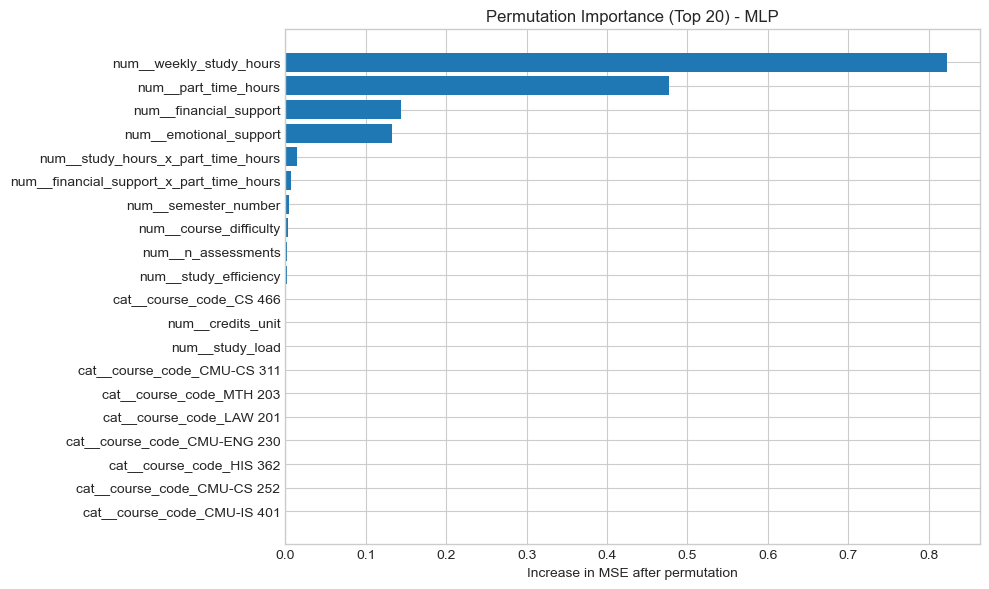

In [3]:
run_importance = True

if run_importance:
    imps = torch_permutation_importance(
        model,
        X_test_tensor,
        y_test,
        n_repeats=3,
        sample_size=5000
    )

    # Top 20
    top_k = 20
    top_idx = np.argsort(imps)[::-1][:top_k]
    top_features = [feature_names[i] for i in top_idx]
    top_scores = imps[top_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_scores[::-1])
    plt.xlabel("Increase in MSE after permutation")
    plt.title("Permutation Importance (Top 20) - MLP")
    plt.tight_layout()
    plt.show()

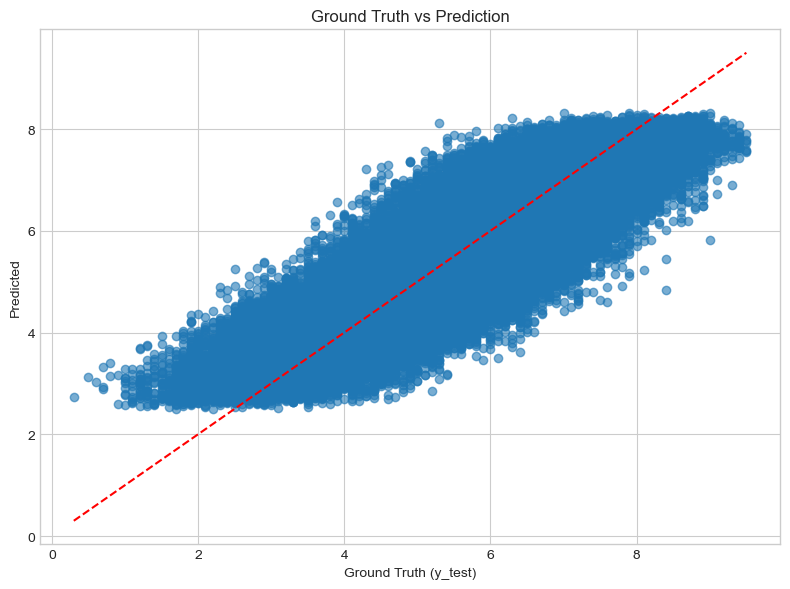

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Ground Truth (y_test)')
plt.ylabel('Predicted')
plt.title('Ground Truth vs Prediction')
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
errors = y_test - y_pred_test
plt.figure(figsize=(8,6))
sns.histplot(errors, bins=30, kde=True)
plt.title("Phân phối sai số (y_test - y_pred)")
plt.xlabel("Sai số")
plt.ylabel("Tần suất")
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

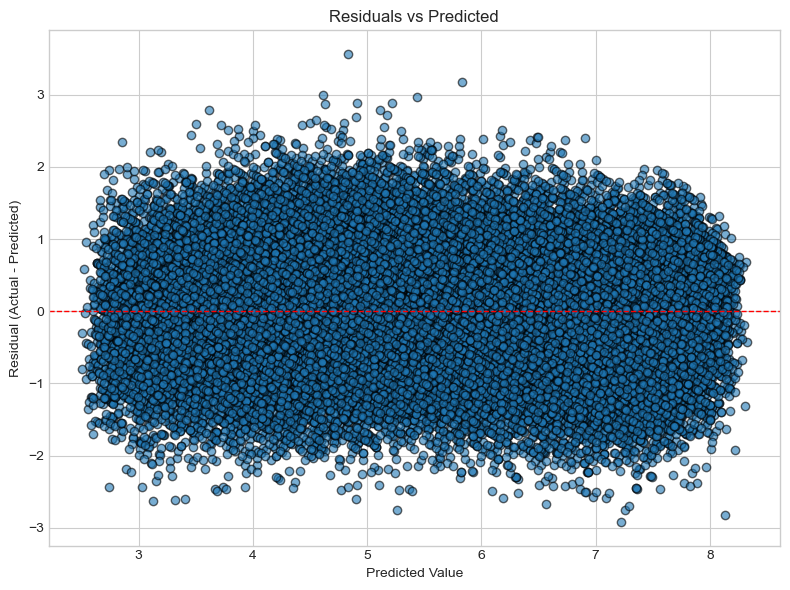

In [10]:
residuals = y_test.values - y_pred_test

# Vẽ biểu đồ Residuals vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.6, edgecolors='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()